In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


import sys
sys.path.append("../utils")
from plotting_utils import format_top_3, plot_metric_grouped_by, plot_bio_vs_batch_correction,  plot_bio_vs_batch_correction_markers

In [2]:
%load_ext autoreload
%autoreload 2

In [16]:
# base_path = "/home/mila/m/myriam.lizotte/RF-MALI"
# mali_path = "/home/mila/m/myriam.lizotte/MALI"
# scratch_path = "/home/mila/m/myriam.lizotte/scratch/RF-MALI"

# save_name = f"real_batches" #dataset}".format(dataset = dataset_name)
# save_path = f"{scratch_path}/results/{save_name}"


# results_path = "/home/lizottem/RF-MALI/results"
results_path = "/NOBACKUP/lizottem/fosta/results"
exp_name = "real_batches_lung"
# timestamp = "2026-05-01_01-25-45"
timestamp = "masking/2026-05-03_20-04-28"
save_name = f"real_batches_lung/{timestamp}" #dataset}".format(dataset = dataset_name)
save_path = f"{results_path}/{save_name}"


create a new summary df based on aggregating the dfs in the n_comp subfolders (only needs to be ran once)

In [ ]:
# batches = ["1","2","3","4","5","6", "A1", "A2", "A3", "A4", "A5", "A6", "B1", "B2", "B3", "B4"]
# batches = ["A1", "A2", "A3", "A4", "A5", "A6"]
# seeds = [11784, 39041, 56089, 79121, 4386721]

# all_results_df = pd.DataFrame()
# for i1, batch1 in enumerate(batches):
#     for i2, batch2 in enumerate(batches):
#         if i1 >= i2:
#             continue
    
#         for seed in seeds:
#             save_path_subfolder = f"{save_path}/{batch1}_{batch2}/seed_{seed}"
#             try:
#                 df = pd.read_csv(f"{save_path_subfolder}/{exp_name}_results.csv")
#             except FileNotFoundError:
#                 df = pd.DataFrame()
#                 print(f"File not found: {save_path_subfolder}/{exp_name}_results.csv")

#             df["batch1"] = batch1
#             df["batch2"] = batch2
#             all_results_df = pd.concat([all_results_df, df], ignore_index=True)
                
# all_results_df    
# all_results_df.to_csv(f"{save_path}/{exp_name}_with_batches_results.csv", index=False)
                

File not found: /NOBACKUP/lizottem/fosta/results/real_batches_lung/2026-05-01_01-25-45/A1_A3/seed_79121/real_batches_lung_results.csv
File not found: /NOBACKUP/lizottem/fosta/results/real_batches_lung/2026-05-01_01-25-45/A2_A4/seed_39041/real_batches_lung_results.csv


In [12]:
save_name

'real_batches_lung/2026-04-26_23-27-42'

# Real batches data

In [17]:
# load results
exp_name = "real_batches_lung"
results_df = pd.read_csv(f"{save_path}/{exp_name}_results.csv")


metric_type = results_df.loc[results_df["method"] == "Metric Type"]
metric_type = metric_type.drop(columns=['method']).drop_duplicates()
results_df = results_df.loc[results_df["method"] != "Metric Type"]


# # convert relevant columns to numeric
num_cols = results_df.columns.difference(['method', 'batch1', 'batch2'])
results_df[num_cols] = results_df[num_cols].apply(pd.to_numeric, errors='coerce')


# results_df = results_df.drop(0, axis = 0) # remove one run from debugging
# results_df.drop_duplicates(subset=['method'], keep='last', inplace=True)


# delete rows where n_components is NA
results_df = results_df.loc[~results_df["n_components"].isna()]


# remove n_components in the model column (it was just used to not overwrite adata, and it's already another column)
results_df["method"] = results_df["method"].str.replace(r'_\d+_components', '', regex=True)

In [18]:
# rename FOSTA PHATE t2 to FoSTA
results_df["method"] = results_df["method"].replace({"FoSTA_PHATE_t2": "FoSTA"})
results_df["method"] = results_df["method"].replace({"RFMALI_PHATE_t2": "RFMALI"})

methods_to_remove= ["RFMALI"]
methods_to_remove+= ["Harmony"]  # remove Harmony because it has 30 components, not comparable
results_df = results_df[~results_df["method"].isin(methods_to_remove)]

In [9]:
results_df

,seed,n_components,method,Isolated labels,Leiden NMI,Leiden ARI,KMeans NMI,KMeans ARI,Silhouette label,cLISI,...,PCR comparison,Batch correction,Bio conservation,Total,cell_cycle_score,time,memory,batch2,batch1,folder
0,11784,2,Unintegrated,0.623492,0.856104,0.874786,0.690801,0.485286,0.665566,0.999839,...,0.000000,0.462540,0.742268,0.630376,NaN,NaN,NaN,NaN,NaN,NaN
1,11784,2,Old FoSTA kerf t=2,0.621444,0.623065,0.390371,0.646032,0.471937,0.687793,1.000000,...,0.928724,0.585994,0.634377,0.615024,0.694353,73.016186,235.021749,NaN,NaN,NaN
2,11784,2,Old FoSTA kerf t=auto,0.617091,0.610684,0.374799,0.674224,0.626001,0.678757,1.000000,...,0.947625,0.585281,0.654508,0.626817,0.691237,141.143915,249.333890,NaN,NaN,NaN
3,11784,2,Old FoSTA gap t=2,0.543429,0.660371,0.523428,0.659270,0.582073,0.731165,1.000000,...,0.997608,0.704605,0.671391,0.684676,0.855083,30.434055,206.833932,NaN,NaN,NaN
4,11784,2,Old FoSTA gap t=auto,0.482331,0.629202,0.428024,0.661842,0.569084,0.720423,0.999944,...,0.996380,0.707111,0.641550,0.667775,0.782696,75.852679,242.136525,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2601,4386721,2,scVI,NaN,0.571040,0.294409,0.554388,0.281891,0.557565,0.993373,...,0.707150,0.685083,0.542111,0.599300,0.744451,239.751971,32.303485,A6,A5,NaN
2602,4386721,2,scANVI,NaN,0.662445,0.342224,0.685248,0.427440,0.659285,1.000000,...,0.625886,0.704252,0.629440,0.659365,0.652430,246.828623,35.250498,A6,A5,NaN
2603,4386721,2,Pamona,NaN,0.517194,0.231454,0.502080,0.211095,0.494649,0.994008,...,0.999630,0.590115,0.491747,0.531094,0.753016,177.366549,1357.944167,A6,A5,NaN
2604,4386721,2,KEMArbf,NaN,0.531356,0.266716,0.380768,0.132098,0.603070,0.983526,...,0.830351,0.686910,0.482922,0.564518,0.532024,1.115601,5.947020,A6,A5,NaN


# make plots

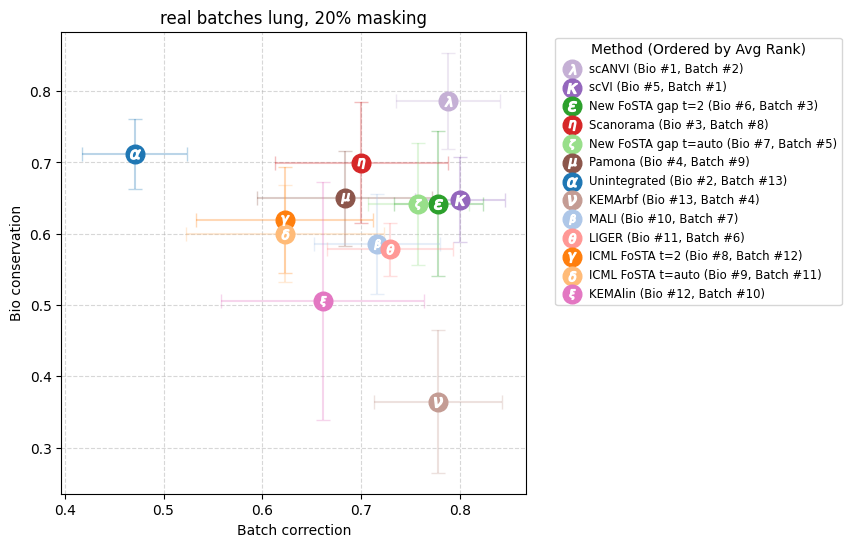

In [21]:
plot_bio_vs_batch_correction_markers(results_df, "real batches lung, 20% masking")

In [14]:
results_df.value_counts(["seed"])

seed   
56089      525
4386721    503
79121      490
39041      424
11784      393
Name: count, dtype: int64

In [15]:
results_df.value_counts(["batch1", "batch2"])

batch1  batch2
A2      A3        95
A1      A6        95
        A5        95
A2      A6        95
        A5        95
A1      A2        89
        A4        89
A3      A6        89
A4      A5        89
A3      A4        89
        A5        89
A4      A6        89
A5      A6        83
A2      A4        76
A1      A3        70
Name: count, dtype: int64

/home/mila/m/myriam.lizotte/RF-MALI/notebooks/../utils/plotting_utils.py:280: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  title=groupby_cols[1],


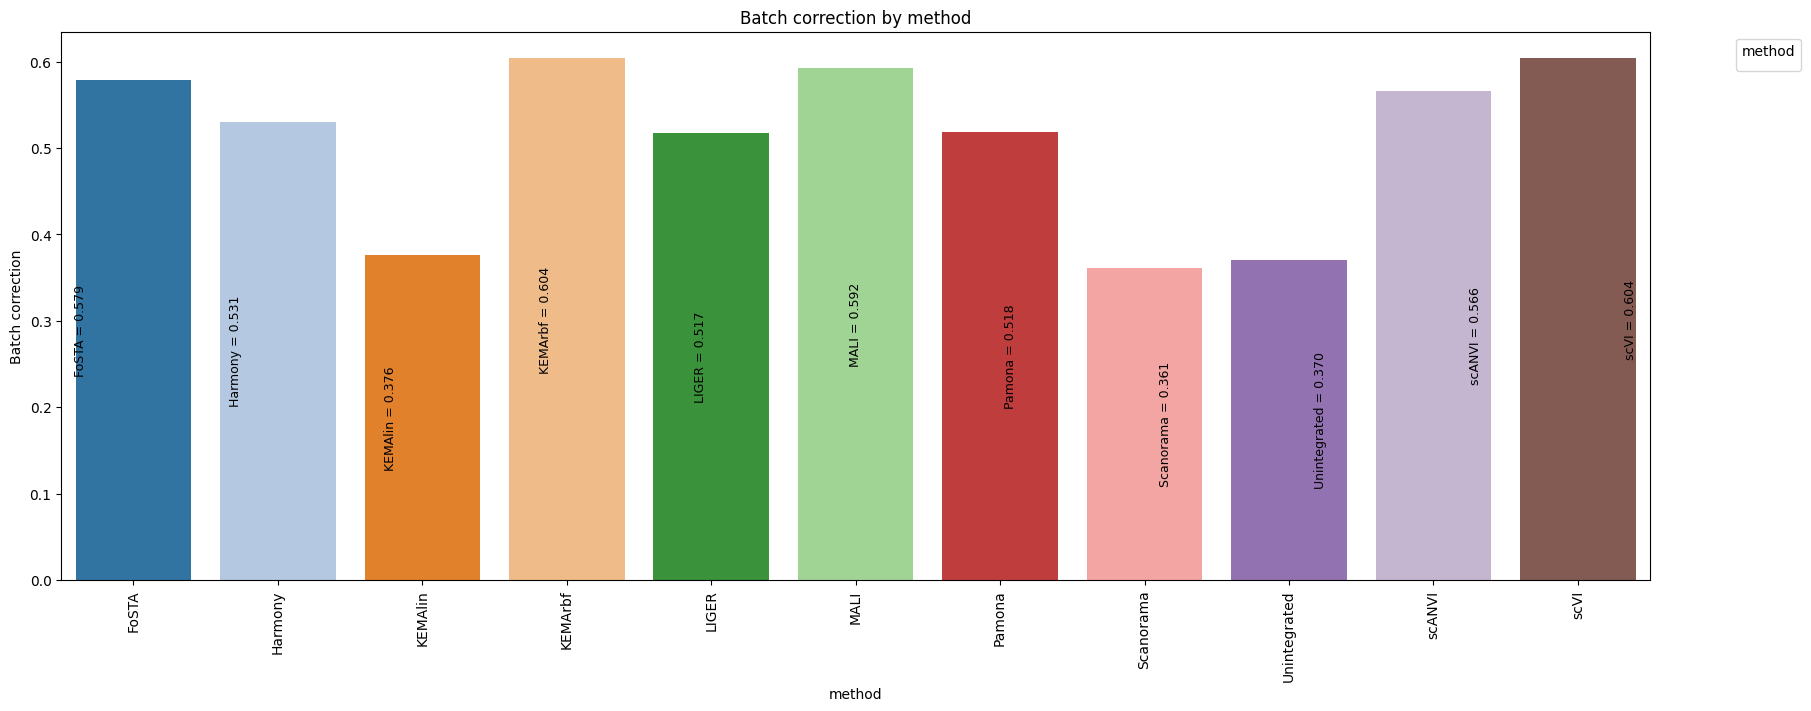

/home/mila/m/myriam.lizotte/RF-MALI/notebooks/../utils/plotting_utils.py:280: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  title=groupby_cols[1],


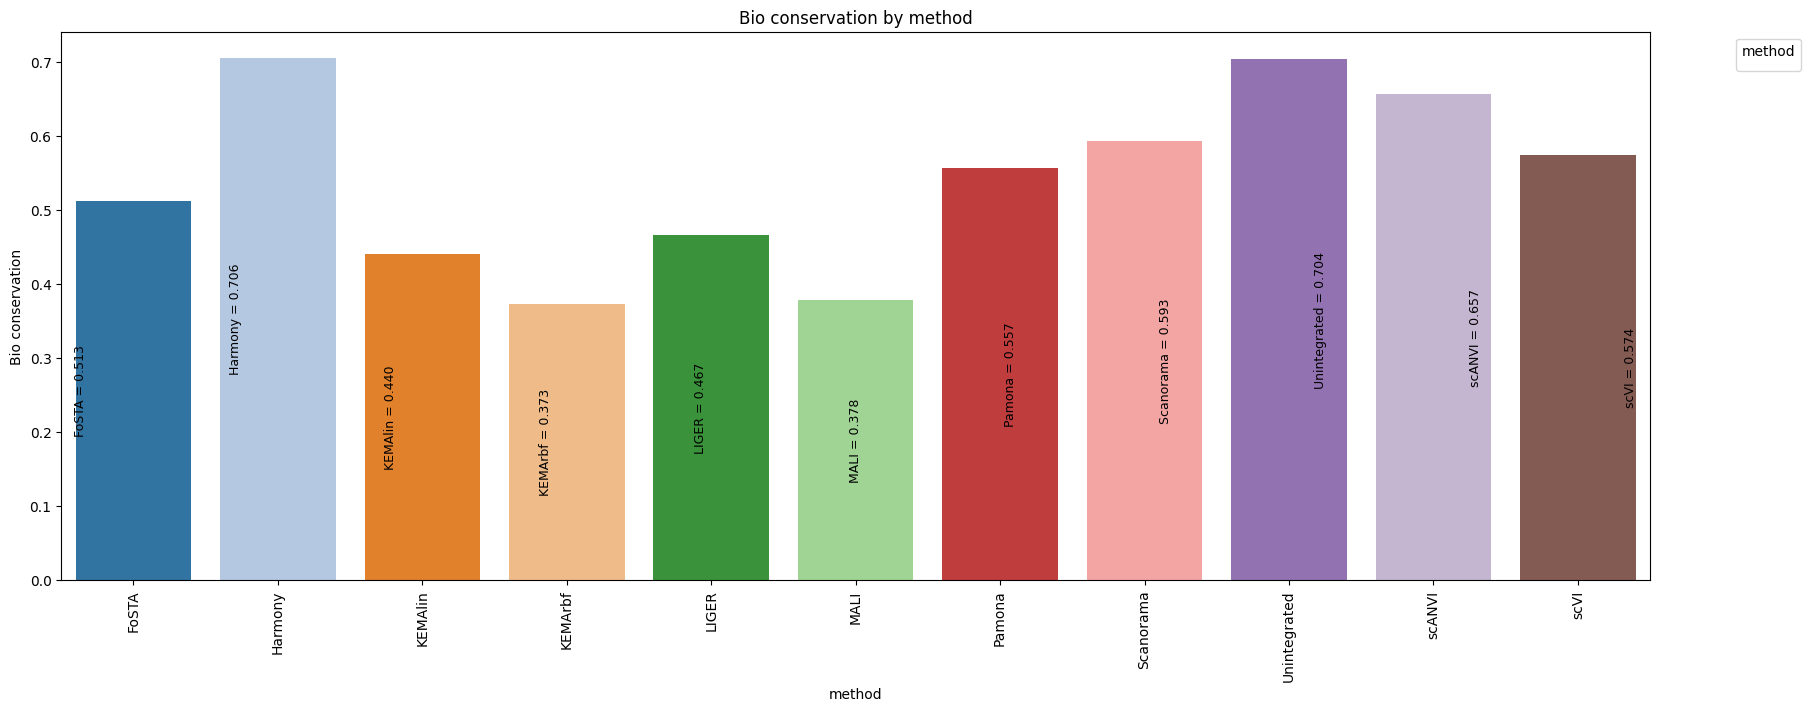

/home/mila/m/myriam.lizotte/RF-MALI/notebooks/../utils/plotting_utils.py:280: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  title=groupby_cols[1],


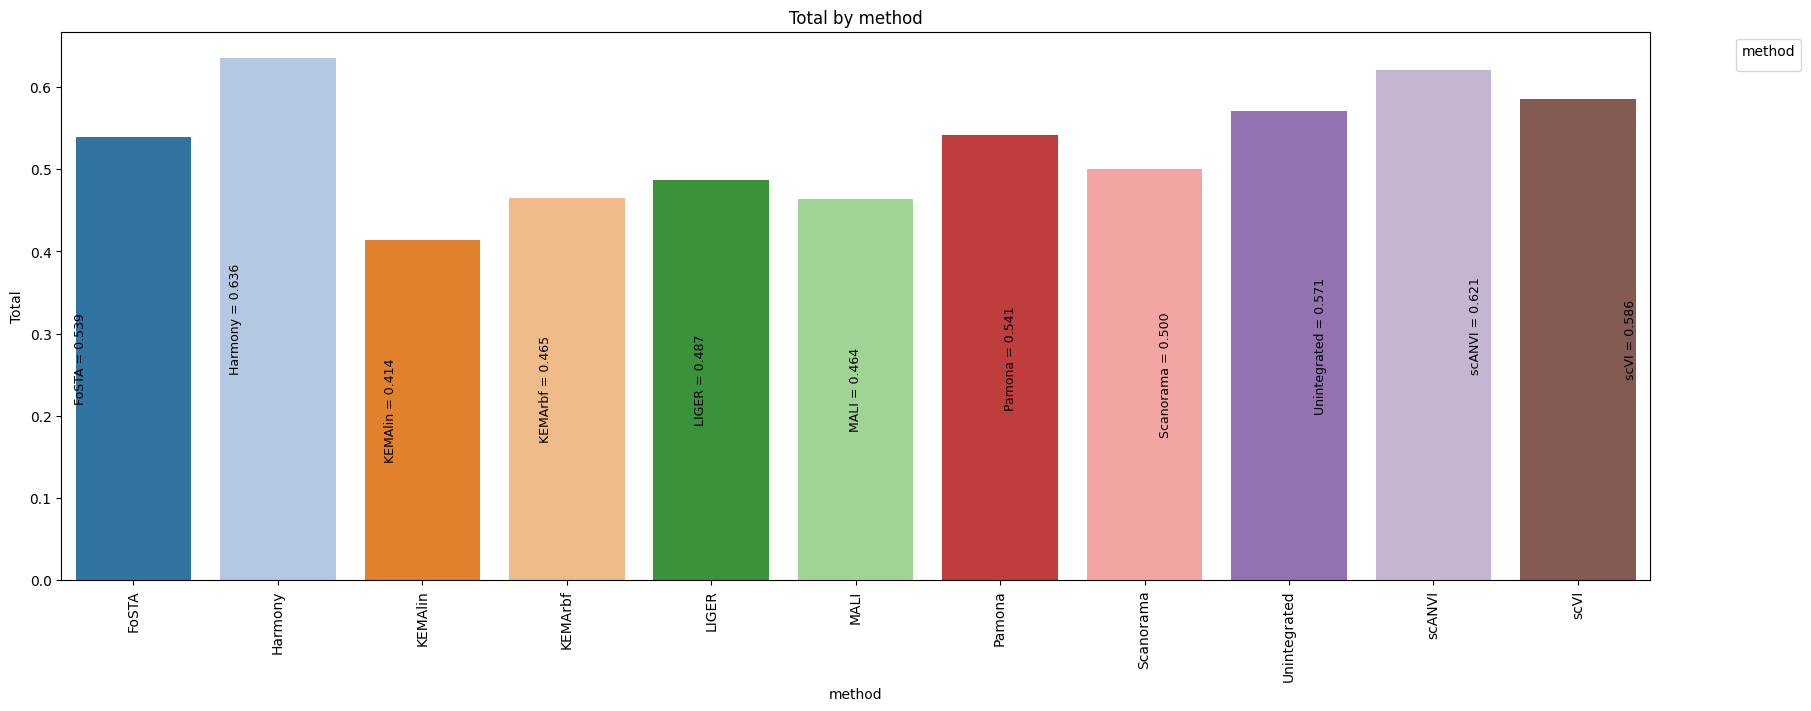

In [52]:
plot_metric_grouped_by(results_df, groupby_cols=["method"])

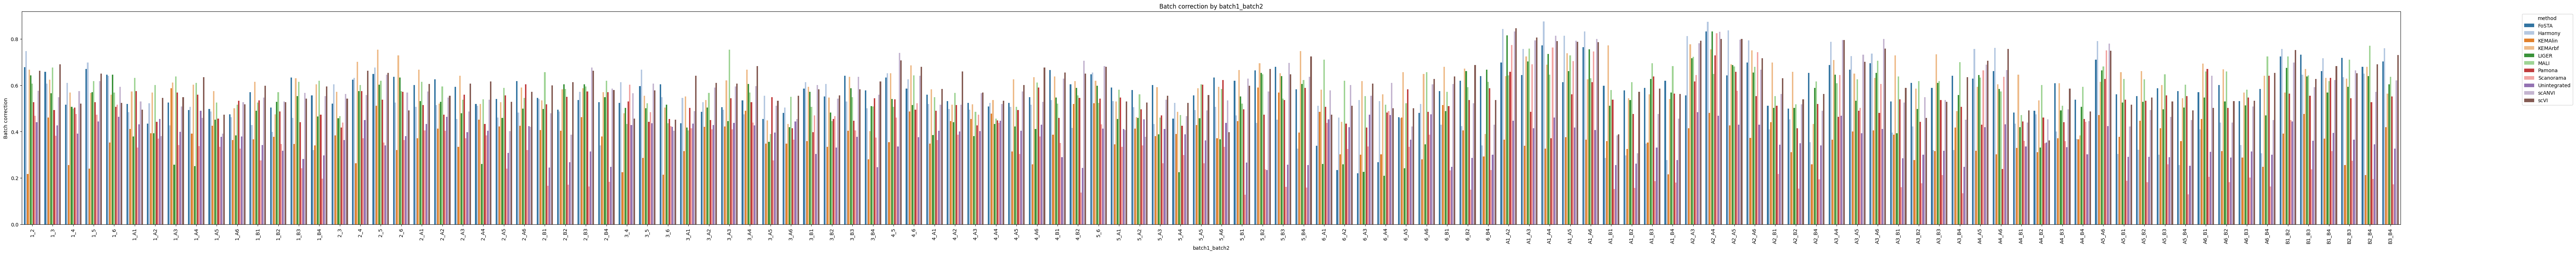

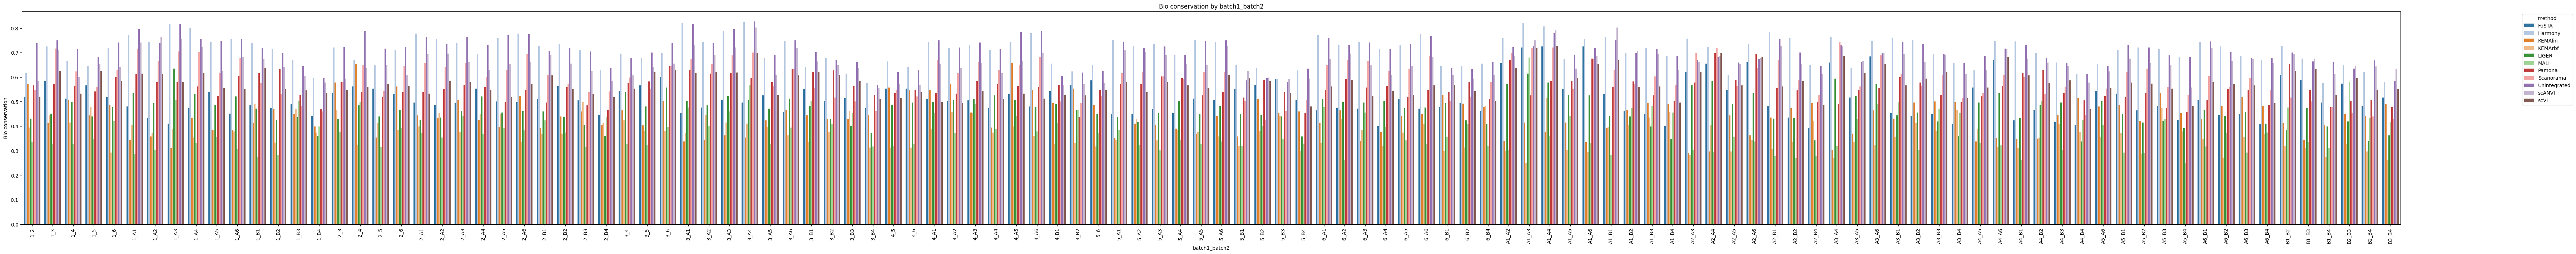

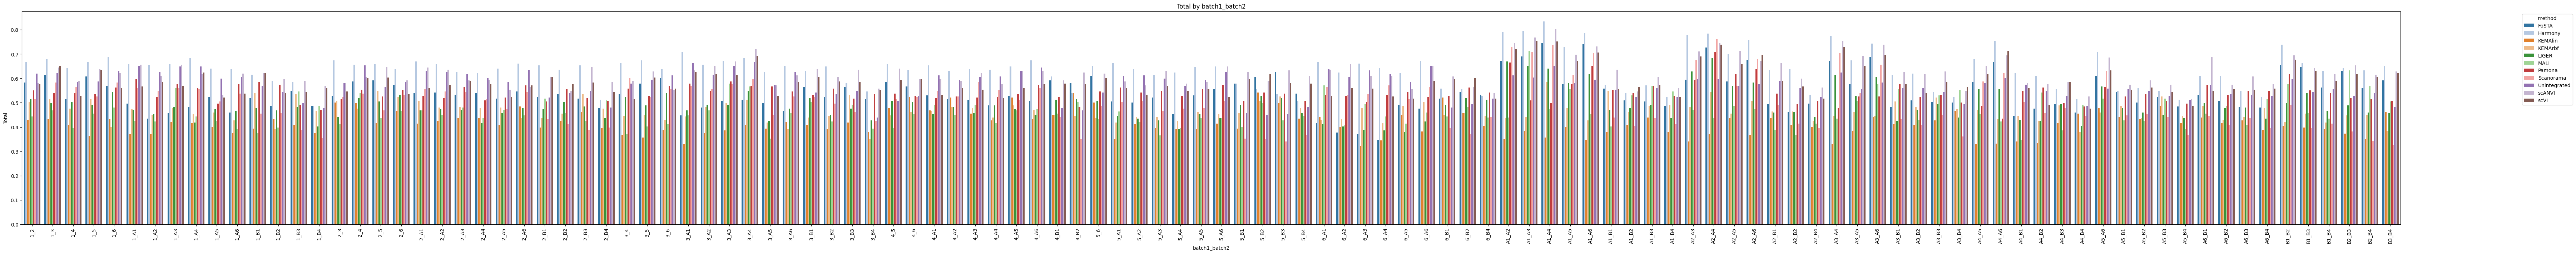

In [12]:
plot_metric_grouped_by(results_df, groupby_cols=["batch1_batch2", "method"], annotate=False, fig_len_factor=4)

In [8]:
results_df["batch1_batch2"] = results_df["batch1"] + "_" + results_df["batch2"]

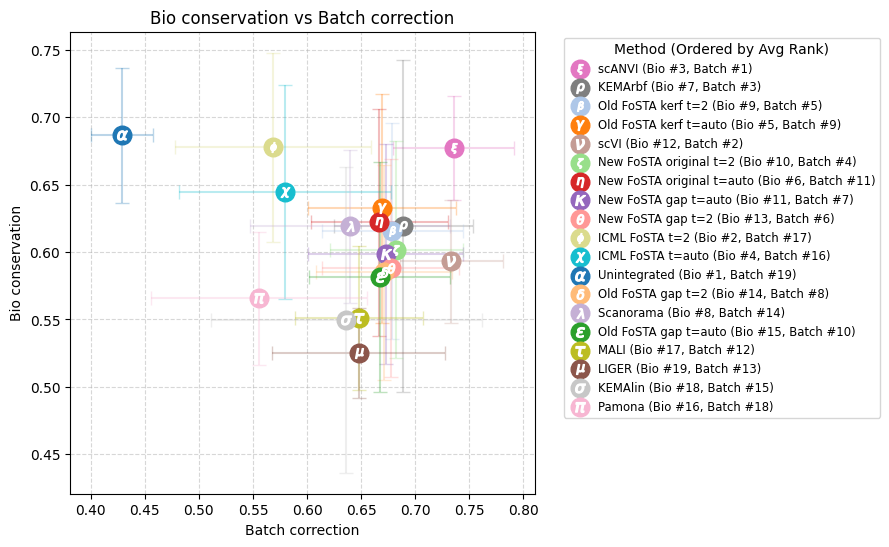

In [13]:
plot_bio_vs_batch_correction_markers(results_df)

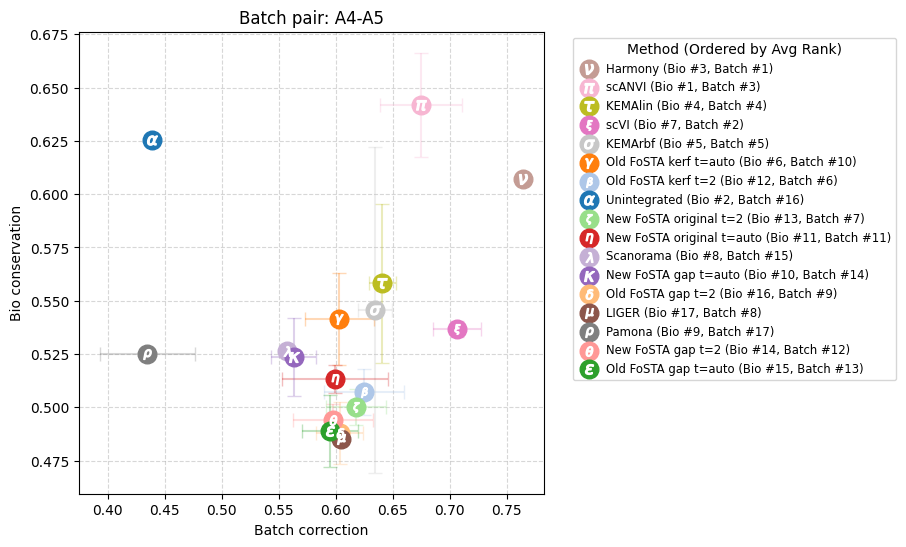

In [28]:
batch1 = "A4"
batch2 = "A5"
results_subset = results_df[(results_df["batch1"] == batch1) & (results_df["batch2"] == batch2)]
plot_bio_vs_batch_correction_markers(results_subset, title="Batch pair: {}-{}".format(batch1, batch2))

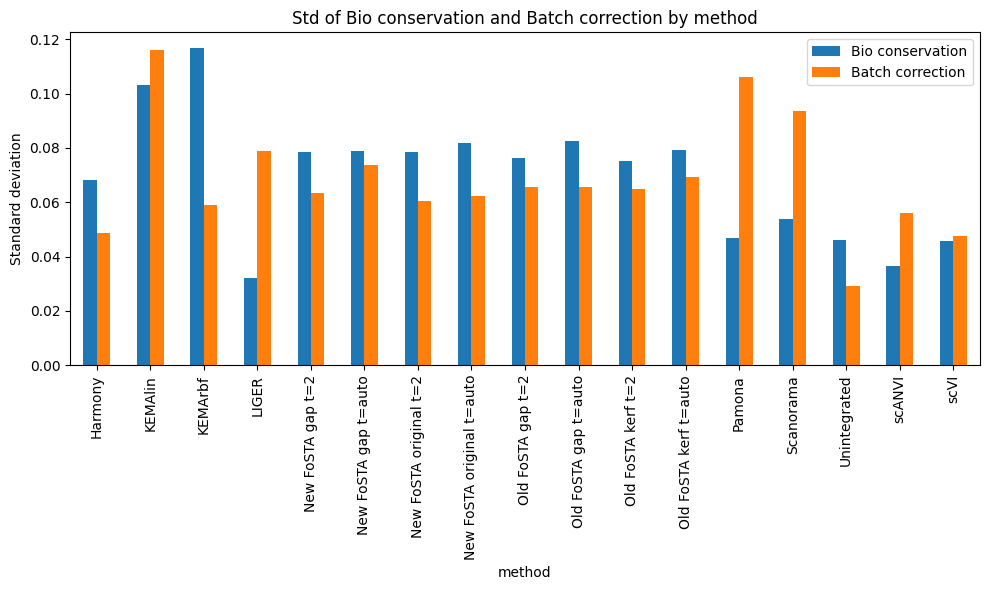

In [30]:
# bar plot of the std over bio conservation and batch correction for each method
std_df = (
    results_df.groupby("method")[["Bio conservation", "Batch correction"]]
    .std()
    .fillna(0)
)

ax = std_df.plot(kind="bar", figsize=(10, 6))
ax.set_ylabel("Standard deviation")
ax.set_title("Std of Bio conservation and Batch correction by method")
plt.tight_layout()
plt.show()

In [33]:
std_df = results_df.groupby(['method', 'batch1', 'batch2'])[["Bio conservation", "Batch correction"]].std()
std_df = std_df.fillna(0)


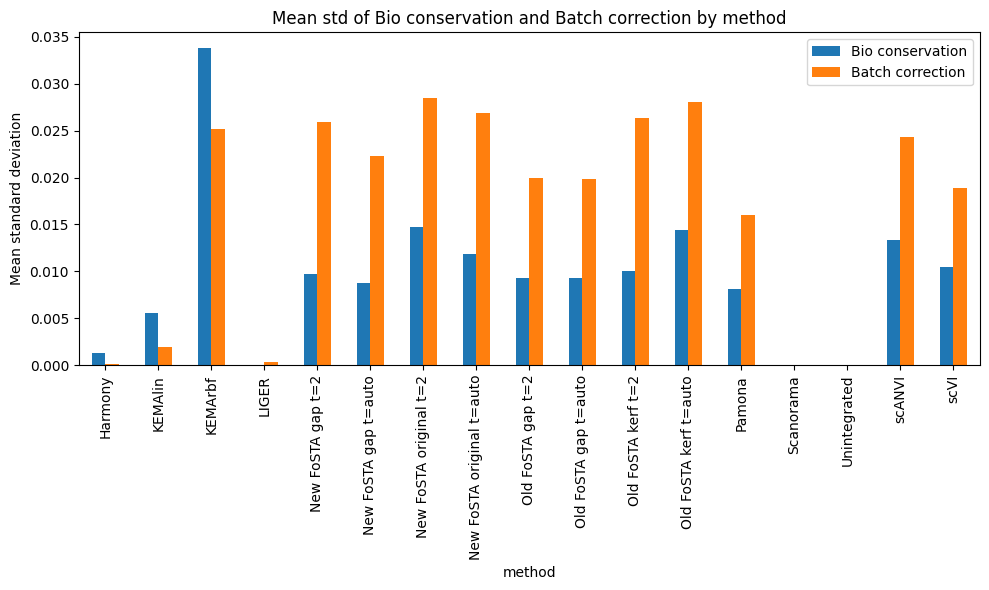

In [35]:
std_df.groupby("method")[["Bio conservation", "Batch correction"]].mean().plot(kind="bar", figsize=(10, 6))
plt.ylabel("Mean standard deviation")
plt.title("Mean std of Bio conservation and Batch correction by method")
plt.tight_layout()

In [27]:
results_df["batch_pair"] = f"{results_df['batch1']}_{results_df['batch2']}"
results_df["batch_pair"].unique()

array(['0      1\n1      1\n2      1\n3      1\n4      1\n      ..\n804    3\n805    3\n806    3\n807    3\n808    3\nName: batch1, Length: 756, dtype: int64_0      2\n1      2\n2      2\n3      2\n4      2\n      ..\n804    6\n805    6\n806    6\n807    6\n808    6\nName: batch2, Length: 756, dtype: object'],
      dtype=object)

In [28]:
results_df

,n_components,method,Isolated labels,Leiden NMI,Leiden ARI,KMeans NMI,KMeans ARI,Silhouette label,cLISI,BRAS,...,PCR comparison,Batch correction,Bio conservation,Total,cell_cycle_score,time,memory,batch1,batch2,batch_pair
0,2.0,Unintegrated,0.687804,0.853471,0.805380,0.699387,0.447650,0.615891,0.990031,0.669590,...,0.000000,0.505223,0.728517,0.639199,NaN,NaN,NaN,1,2,0 1\n1 1\n2 1\n3 1\n4 ...
1,2.0,FoSTA_PHATE_tauto,0.515022,0.496456,0.284032,0.547684,0.471374,0.513882,0.914289,0.293947,...,0.987903,0.674030,0.534677,0.590418,0.988055,115.056723,362.144176,1,2,0 1\n1 1\n2 1\n3 1\n4 ...
2,2.0,FoSTA_PHATE_t2,0.530315,0.492440,0.291186,0.495585,0.276569,0.504763,0.921057,0.282829,...,0.977223,0.647339,0.501702,0.559957,0.799613,56.858186,362.028246,1,2,0 1\n1 1\n2 1\n3 1\n4 ...
3,2.0,FoSTA_PHATE_OOB,0.462085,0.526053,0.262254,0.522416,0.224502,0.523978,0.928021,0.376374,...,0.989575,0.755772,0.492758,0.597964,0.589758,96.711996,344.720539,1,2,0 1\n1 1\n2 1\n3 1\n4 ...
4,2.0,FoSTA_PHATE_denseOT,0.474352,0.475784,0.259987,0.482023,0.281769,0.485581,0.919394,0.274881,...,0.957517,0.617160,0.482698,0.536483,0.462922,31.877904,361.995514,1,2,0 1\n1 1\n2 1\n3 1\n4 ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
804,2.0,scVI,0.977710,0.661020,0.443054,0.608231,0.381267,0.585880,0.996892,0.389344,...,0.215120,0.461964,0.664865,0.583705,0.603551,330.550792,29.814746,3,6,0 1\n1 1\n2 1\n3 1\n4 ...
805,2.0,scANVI,0.956204,0.669741,0.402544,0.728932,0.574414,0.667499,0.999949,0.386593,...,0.000000,0.424120,0.714183,0.598158,0.574335,330.149572,30.472469,3,6,0 1\n1 1\n2 1\n3 1\n4 ...
806,2.0,Pamona,0.985498,0.610185,0.333380,0.629437,0.383247,0.532343,0.999697,0.366192,...,0.890274,0.526029,0.639112,0.593879,0.605715,123.007847,1013.828086,3,6,0 1\n1 1\n2 1\n3 1\n4 ...
807,2.0,KEMArbf,0.477157,0.398519,0.161216,0.328617,0.152968,0.534493,0.918699,0.496073,...,0.000000,0.465248,0.424524,0.440813,0.511825,1.154086,4.892303,3,6,0 1\n1 1\n2 1\n3 1\n4 ...


# only consider batches within the same set

In [54]:
def get_set_of_batch(batch):
    if batch.startswith("A"):
        return "A"
    elif batch.startswith("B"):
        return "B"
    else:
        return "0"
    
results_df["same_batch_set"] = (results_df["batch1"].apply(get_set_of_batch) == results_df["batch2"].apply(get_set_of_batch))

In [58]:
same_batch_results_df = results_df.loc[results_df["same_batch_set"] == True]

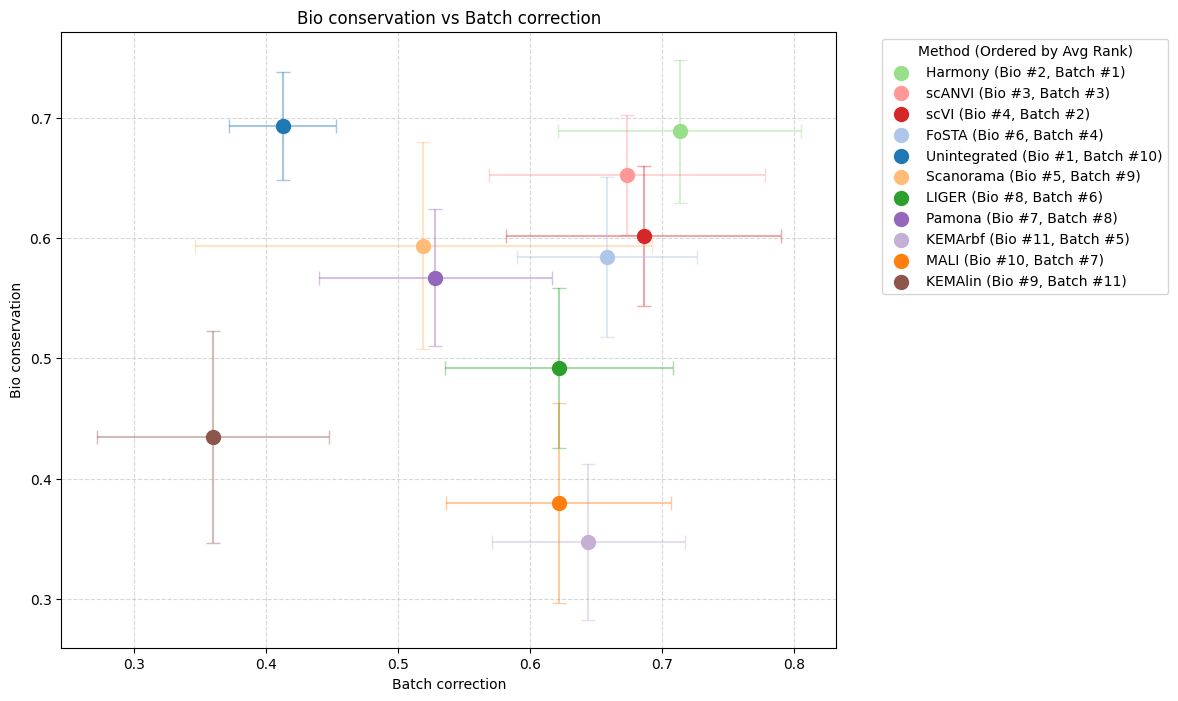

In [60]:
plot_bio_vs_batch_correction(same_batch_results_df)